# Практическая работа № 1
## Учебные блоки: анализ `FiresRu.csv`

**Цель:** пройти базовый цикл анализа табличных данных: настроить окружение, загрузить и диагностировать данные, выполнить предобработку и EDA, построить визуализации и проверить экспорт.

**Источник:** набор «Метеорологические условия пожаров на территории России (2021-2022)», предоставленный вместе с заданием. В таблице нет даты/времени; поэтому временной ряд по ней не строится. Единицы `relative_humidity` и `solar_radiation` в исходных метаданных явно не заданы, и ниже им не приписываются неподтверждённые единицы.

### 2.1. Рабочее окружение

Используется локальное окружение `.venv`. Версии фиксируются непосредственно при выполнении notebook, чтобы результат можно было воспроизвести.

In [1]:
from pathlib import Path
import io
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

NOTEBOOK_DIR = Path.cwd()
DATA_PATH = (NOTEBOOK_DIR.parent / "FiresRu.csv").resolve()
OUT = NOTEBOOK_DIR / "output" / "fires"
OUT.mkdir(parents=True, exist_ok=True)
print("Данные:", DATA_PATH)
print("Результаты:", OUT.resolve())

Python: 3.12.2
pandas: 3.0.1
NumPy: 2.4.2
Matplotlib: 3.10.8
Данные: /Users/gankolcherin/myfolder/mirea-4/mirea-4-1/subjects/tiabd/1/FiresRu.csv
Результаты: /Users/gankolcherin/myfolder/mirea-4/mirea-4-1/subjects/tiabd/1/submission/output/fires


**Интерпретация.** Все библиотеки импортированы без ошибок, а пути строятся относительно каталога запуска notebook. Это отделяет код от абсолютных путей конкретного компьютера.

### 3.1. Векторное преобразование в NumPy

In [2]:
wind_ms = np.array([1.14, 0.80, 0.97])
wind_kmh = wind_ms * 3.6
print(np.round(wind_kmh, 2))

[4.1  2.88 3.49]


**Интерпретация.** Одно выражение применило формулу $v_{км/ч}=3.6 \cdot v_{м/с}$ ко всему массиву без построчного цикла. Результат: 4.10, 2.88 и 3.49 км/ч.

### 3.2. `Series`, `DataFrame` и `groupby()`

In [3]:
s = pd.Series([10, 20, 30], name="value")
frame = pd.DataFrame({"type": ["A", "B", "A"], "value": [10, 20, 30]})
print(type(s).__name__)
print(type(frame).__name__)
display(frame.groupby("type")["value"].sum())

Series
DataFrame


type
A    40
B    20
Name: value, dtype: int64

**Интерпретация.** `Series` — одномерный именованный массив с индексом, а `DataFrame` — таблица согласованных столбцов. `groupby()` реализует схему «разбить по категории → агрегировать»: сумма для A равна 40, для B — 20.

### 4. Форматы хранения и загрузка CSV

In [4]:
formats = pd.DataFrame({
    "Организация": ["строки и разделители", "объекты/массивы", "колоночный бинарный"],
    "Схема": ["встроенной строгой схемы нет", "типы выражены структурой JSON", "сохраняется"],
    "Сильная сторона": ["совместимость и читаемость", "вложенные структуры", "сжатие, типы, выборочное чтение"],
    "Ограничение": ["типы выводятся заново", "избыточен для таблиц", "нужен специальный reader"],
}, index=["CSV", "JSON", "Parquet"])
display(formats)

df = pd.read_csv(DATA_PATH, sep=",", encoding="utf-8")
print("Форма:", df.shape)
print("Столбцы:", df.columns.tolist())
display(df.head())
assert df.shape == (26681, 9)

,Организация,Схема,Сильная сторона,Ограничение
CSV,строки и разделители,встроенной строгой схемы нет,совместимость и читаемость,типы выводятся заново
JSON,объекты/массивы,типы выражены структурой JSON,вложенные структуры,избыточен для таблиц
Parquet,колоночный бинарный,сохраняется,"сжатие, типы, выборочное чтение",нужен специальный reader


Форма: (26681, 9)
Столбцы: ['type_name', 'type_id', 'lon', 'lat', 'temperature_c', 'precipitation_mm', 'relative_humidity', 'wind_speed_ms', 'solar_radiation']


,type_name,type_id,lon,lat,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
0,Natural fire,4,131.5866,47.8662,-9.44,0.01,72.98,1.14,4.59
1,Natural fire,4,131.5885,47.8809,-9.44,0.01,72.98,1.14,4.59
2,Forest fire,3,131.9871,48.4973,-10.71,0.05,81.31,0.80,4.24
3,Natural fire,4,131.9031,43.6277,-7.77,0.00,68.41,0.97,4.66
4,Natural fire,4,131.5706,47.8581,-9.44,0.01,72.98,1.14,4.59


**Интерпретация.** Файл читается с разделителем `,` и кодировкой UTF-8 как таблица из 26 681 строк и 9 столбцов. В перечне полей нет времени, поэтому индекс строк нельзя подменять временной осью.

### 5.1. Структура, типы и память

In [5]:
buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())

<class 'pandas.DataFrame'>
RangeIndex: 26681 entries, 0 to 26680
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type_name          26681 non-null  str    
 1   type_id            26681 non-null  int64  
 2   lon                26681 non-null  float64
 3   lat                26681 non-null  float64
 4   temperature_c      26681 non-null  float64
 5   precipitation_mm   26681 non-null  float64
 6   relative_humidity  26681 non-null  float64
 7   wind_speed_ms      26681 non-null  float64
 8   solar_radiation    26681 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 2.1 MB



**Интерпретация.** Все 9 полей заполнены. Семь столбцов распознаны как `float64`, `type_id` — как `int64`, а названия категорий — как строковый dtype `str` (в старых версиях pandas он отображался как `object`). Пять повторяющихся категорий являются кандидатом на `category`.

### 5.2. Пропуски, дубликаты и кардинальность

In [6]:
quality = pd.DataFrame({
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False),
})
display(quality)
print("Полных дубликатов:", int(df.duplicated().sum()))

,missing,unique
type_name,0,5
type_id,0,5
lon,0,25708
lat,0,23547
temperature_c,0,2581
precipitation_mm,0,571
relative_humidity,0,4028
wind_speed_ms,0,532
solar_radiation,0,731


Полных дубликатов: 0


**Интерпретация.** Пропусков и полных дубликатов нет, поэтому удаление строк не требуется. Это не доказывает семантическую корректность: например, пять значений `type_id` выглядят как числа, но обозначают категории.

### 5.3. Соответствие кода и названия категории

In [7]:
type_map = (
    df[["type_id", "type_name"]]
      .drop_duplicates()
      .sort_values("type_id")
)
display(type_map)
assert type_map["type_id"].is_unique and type_map["type_name"].is_unique

,type_id,type_name
33,1,Uncontrolled burn
2991,2,Peat fire
2,3,Forest fire
0,4,Natural fire
9,5,Controlled burn


**Интерпретация.** Пять кодов взаимно однозначно соответствуют пяти названиям. `type_id` можно хранить компактным целым типом, но среднее этого столбца содержательно бессмысленно.

### 5.4. Описательная статистика

In [8]:
numeric_cols = [
    "lon", "lat", "temperature_c", "precipitation_mm",
    "relative_humidity", "wind_speed_ms", "solar_radiation",
]
display(df[numeric_cols].describe().round(2).T)

,count,mean,std,min,25%,50%,75%,max
lon,26681.0,106.35,27.31,20.37,82.41,96.56,133.90,175.87
lat,26681.0,57.53,4.30,41.71,53.95,58.97,60.64,70.33
temperature_c,26681.0,17.89,5.68,-34.88,15.70,19.08,21.39,31.94
precipitation_mm,26681.0,0.46,1.46,0.00,0.00,0.04,0.30,25.85
relative_humidity,26681.0,69.44,11.43,24.70,62.93,71.35,77.91,99.83
wind_speed_ms,26681.0,0.63,0.93,0.00,0.11,0.25,0.66,7.42
solar_radiation,26681.0,5.57,1.50,0.42,4.55,5.68,6.71,8.97


**Интерпретация.** Температура лежит в диапазоне от -34.88 до 31.94 °C при медиане 19.08 °C. Для осадков и скорости ветра максимум заметно выше верхнего квартиля, что указывает на правые хвосты и требует отдельной проверки необычных значений. Единицы влажности и солнечной радиации из файла не выводятся.

### 6.1. Предобработка и оптимизация типов

In [9]:
before = df.memory_usage(deep=True).sum()
clean_df = df.copy()
clean_df["type_name"] = clean_df["type_name"].astype("category")
clean_df["type_id"] = clean_df["type_id"].astype("int8")
after = clean_df.memory_usage(deep=True).sum()

print(f"До: {before / 1024**2:.2f} MiB")
print(f"После: {after / 1024**2:.2f} MiB")
print(f"Снижение: {(1 - after / before) * 100:.1f}%")
assert len(clean_df) == len(df)

До: 2.13 MiB
После: 1.48 MiB
Снижение: 30.8%


**Интерпретация.** Оптимизация меняет представление, а не смысл данных: все строки сохранены. `category` хранит повторяющиеся названия через компактные коды, а диапазон 1-5 безопасно помещается в `int8`. В текущем окружении pandas 3.0 память сократилась на 30.8%; отличие от значения в методичке связано с более компактным новым строковым dtype.

### 6.2. Вычисляемые признаки

In [10]:
clean_df["wind_speed_kmh"] = (clean_df["wind_speed_ms"] * 3.6).round(2)
clean_df["is_forest_fire"] = clean_df["type_name"].eq("Forest fire")
display(clean_df[["type_name", "wind_speed_ms", "wind_speed_kmh", "is_forest_fire"]].head())

,type_name,wind_speed_ms,wind_speed_kmh,is_forest_fire
0,Natural fire,1.14,4.10,False
1,Natural fire,1.14,4.10,False
2,Forest fire,0.80,2.88,True
3,Natural fire,0.97,3.49,False
4,Natural fire,1.14,4.10,False


**Интерпретация.** `wind_speed_kmh = 3.6 * wind_speed_ms` лишь переводит единицу представления. `is_forest_fire` — логическое правило принадлежности категории и может использоваться как бинарный индикатор.

### 7.1. Частоты категорий

In [11]:
type_stats = (
    clean_df["type_name"]
      .value_counts()
      .to_frame("n")
      .assign(share_pct=lambda x: x["n"] / len(clean_df) * 100)
)
display(type_stats.round(2))

,n,share_pct
type_name,,
Forest fire,18415,69.02
Natural fire,5195,19.47
Uncontrolled burn,2711,10.16
Controlled burn,333,1.25
Peat fire,27,0.10


**Интерпретация.** `Forest fire` составляет около 69.02% строк, а `Peat fire` — около 0.10% (27 наблюдений). Категории резко несбалансированы, поэтому средние и будущие модельные метрики следует оценивать с учётом размера групп.

### 7.2. Групповые статистики

In [12]:
group_stats = (
    clean_df.groupby("type_name", observed=True)
      .agg(
          n=("type_name", "size"),
          temp_mean=("temperature_c", "mean"),
          precip_mean=("precipitation_mm", "mean"),
          humidity_mean=("relative_humidity", "mean"),
          wind_mean=("wind_speed_ms", "mean"),
          solar_mean=("solar_radiation", "mean"),
      )
      .sort_values("n", ascending=False)
)
display(group_stats.round(2))

,n,temp_mean,precip_mean,humidity_mean,wind_mean,solar_mean
type_name,,,,,,
Forest fire,18415,18.69,0.50,70.30,0.42,5.87
Natural fire,5195,17.42,0.40,69.07,0.80,5.14
Uncontrolled burn,2711,14.21,0.29,64.35,1.64,4.57
Controlled burn,333,10.78,0.25,69.46,1.46,4.27
Peat fire,27,18.17,0.55,65.47,1.19,5.26


**Интерпретация.** Сначала следует сравнивать `n`, затем средние. Например, статистика `Peat fire` основана только на 27 строках и не обладает той же устойчивостью, что статистика `Forest fire` из 18 415 строк. Различия средних не доказывают причинность.

### 7.3. Составной фильтр через `loc`

In [13]:
subset = clean_df.loc[
    (clean_df["relative_humidity"] < 40) & (clean_df["wind_speed_ms"] > 2),
    ["type_name", "lon", "lat", "temperature_c", "relative_humidity", "wind_speed_ms"],
]
print("Строк в срезе:", len(subset))
display(subset.head())

Строк в срезе: 337


,type_name,lon,lat,temperature_c,relative_humidity,wind_speed_ms
295,Forest fire,91.3929,51.0574,15.15,27.97,2.55
478,Forest fire,104.5843,50.3723,14.67,37.89,2.64
479,Forest fire,104.4937,50.3592,14.67,37.89,2.64
480,Forest fire,104.4187,50.3302,14.67,37.89,2.64
481,Forest fire,104.3001,50.3377,14.67,37.89,2.64


**Интерпретация.** Двум учебным условиям одновременно соответствуют 337 строк. Пороги выбраны для демонстрации логического «И» и не являются нормативным критерием пожарной опасности.

### 8.1. Корреляционная матрица

In [14]:
weather = [
    "temperature_c", "precipitation_mm", "relative_humidity",
    "wind_speed_ms", "solar_radiation",
]
corr = clean_df[weather].corr()
display(corr.round(3))

,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
temperature_c,1.000,0.003,-0.155,-0.297,0.221
precipitation_mm,0.003,1.000,0.232,-0.047,-0.192
relative_humidity,-0.155,0.232,1.000,-0.280,-0.234
wind_speed_ms,-0.297,-0.047,-0.280,1.000,-0.189
solar_radiation,0.221,-0.192,-0.234,-0.189,1.000


**Интерпретация.** Очень сильных линейных связей нет. Наиболее заметные по модулю коэффициенты находятся около 0.30; например, температура и скорость ветра связаны слабо отрицательно. Корреляция около нуля не исключает нелинейной связи и не устанавливает причинность.

### 8.2. Потенциальные выбросы скорости ветра по IQR

In [15]:
q1 = clean_df["wind_speed_ms"].quantile(0.25)
q3 = clean_df["wind_speed_ms"].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_mask = ~clean_df["wind_speed_ms"].between(lower, upper)
print(f"Q1={q1:.3f}; Q3={q3:.3f}; IQR={iqr:.3f}")
print(f"Границы: [{lower:.3f}; {upper:.3f}]")
print(f"Кандидатов: {outlier_mask.sum()} ({outlier_mask.mean() * 100:.2f}% строк)")

Q1=0.110; Q3=0.660; IQR=0.550
Границы: [-0.715; 1.485]
Кандидатов: 3652 (13.69% строк)


**Интерпретация.** Правило IQR помечает 3 652 наблюдения (13.69%). Такая доля больше похожа на выраженный правый хвост распределения, чем на массовую ошибку. Значения не удаляются без проверки источника и предметного обоснования.

### 9.1. Категориальное сравнение

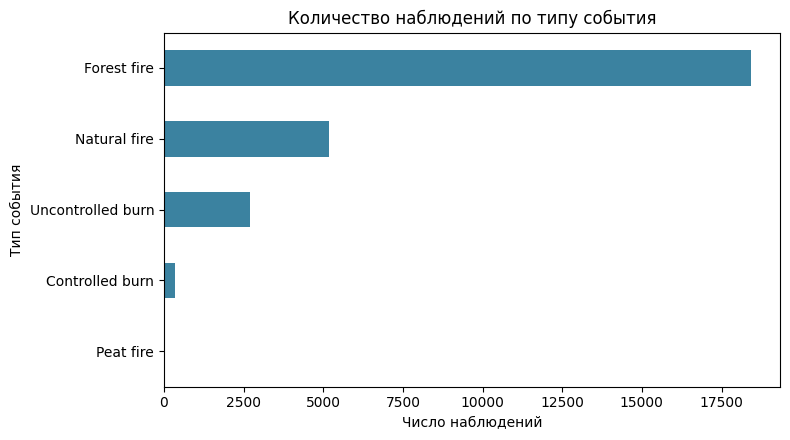

In [16]:
counts = clean_df["type_name"].value_counts().sort_values()
ax = counts.plot(kind="barh", figsize=(8, 4.5), color="#3b82a0")
ax.set_title("Количество наблюдений по типу события")
ax.set_xlabel("Число наблюдений")
ax.set_ylabel("Тип события")
plt.tight_layout()
plt.show()

**Интерпретация.** График наглядно подтверждает доминирование `Forest fire` и крайне малую представленность `Peat fire`.

### 9.2. Распределение температуры

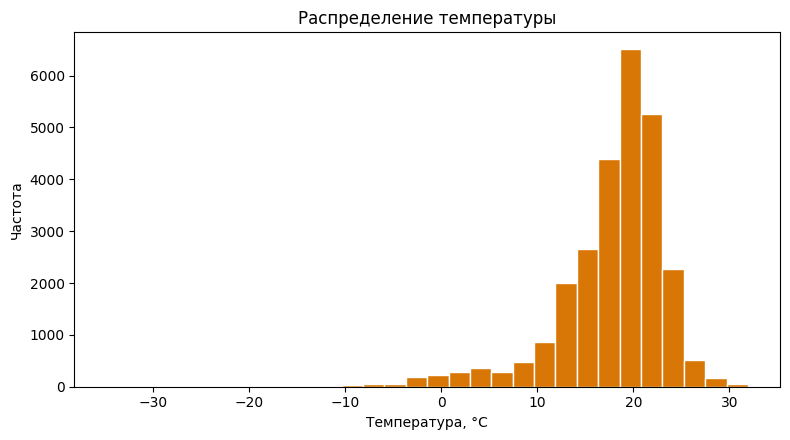

In [17]:
plt.figure(figsize=(8, 4.5))
plt.hist(clean_df["temperature_c"], bins=30, edgecolor="white", color="#d97706")
plt.title("Распределение температуры")
plt.xlabel("Температура, °C")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

**Интерпретация.** Основная масса значений положительна, но заметен длинный левый хвост до -34.88 °C. Сам график не даёт основания объявить эти наблюдения ошибочными.

### 9.3. Температура и относительная влажность

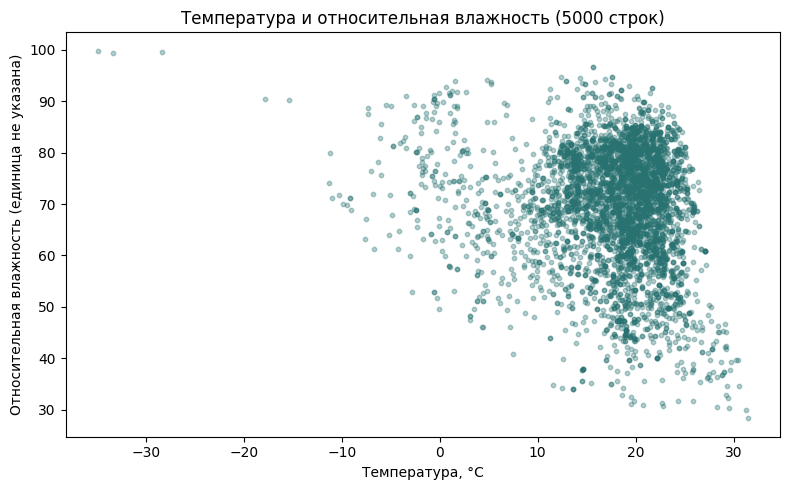

In [18]:
sample = clean_df.sample(n=5000, random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(sample["temperature_c"], sample["relative_humidity"], s=10, alpha=0.35, color="#287271")
plt.title("Температура и относительная влажность (5000 строк)")
plt.xlabel("Температура, °C")
plt.ylabel("Относительная влажность (единица не указана)")
plt.tight_layout()
plt.show()

**Интерпретация.** Широкое облако соответствует слабой отрицательной линейной связи: при росте температуры влажность в среднем немного снижается, но разброс велик.

### 9.4. Пространственная структура

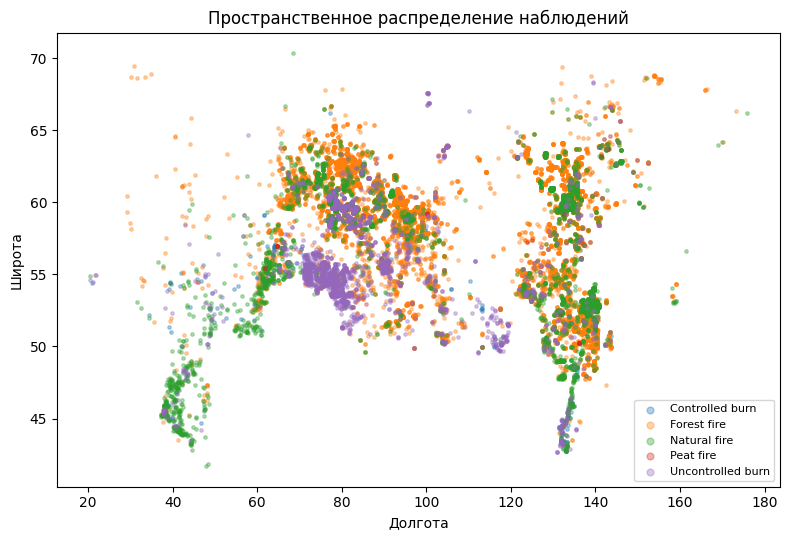

In [19]:
plt.figure(figsize=(8, 5.5))
for name, part in clean_df.groupby("type_name", observed=True):
    plt.scatter(part["lon"], part["lat"], s=6, alpha=0.35, label=name)
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.title("Пространственное распределение наблюдений")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

**Интерпретация.** Наблюдения образуют несколько пространственных кластеров и занимают широкий диапазон координат. Это разведочный scatter plot на декартовых осях, а не карта: полноценная географическая трактовка требует проекции и границ регионов.

### 10. Экспорт и проверка round-trip

In [20]:
fires_csv = OUT / "FiresRu_clean.csv"
fires_json = OUT / "FiresRu_clean.json"
fires_parquet = OUT / "FiresRu_clean.parquet"

clean_df.to_csv(fires_csv, index=False, encoding="utf-8")
clean_df.to_json(fires_json, orient="records", lines=True, force_ascii=False)
clean_df.to_parquet(fires_parquet, index=False, engine="pyarrow", compression="snappy")

size_table = pd.DataFrame({
    "format": ["CSV", "JSON Lines", "Parquet"],
    "size_MiB": [p.stat().st_size / 1024**2 for p in [fires_csv, fires_json, fires_parquet]],
}).set_index("format")
display(size_table.round(3))

csv_back = pd.read_csv(fires_csv)
json_back = pd.read_json(fires_json, lines=True)
parquet_back = pd.read_parquet(fires_parquet)
round_trip = pd.DataFrame({
    "shape": [csv_back.shape, json_back.shape, parquet_back.shape],
    "type_name_dtype": [str(csv_back["type_name"].dtype), str(json_back["type_name"].dtype), str(parquet_back["type_name"].dtype)],
    "type_id_dtype": [str(csv_back["type_id"].dtype), str(json_back["type_id"].dtype), str(parquet_back["type_id"].dtype)],
}, index=["CSV", "JSON Lines", "Parquet"])
display(round_trip)

assert csv_back.shape == clean_df.shape
assert json_back.shape == clean_df.shape
assert parquet_back.shape == clean_df.shape
assert str(parquet_back["type_name"].dtype) == "category"
assert str(parquet_back["type_id"].dtype) == "int8"

,size_MiB
format,
CSV,1.717
JSON Lines,5.814
Parquet,0.606


,shape,type_name_dtype,type_id_dtype
CSV,"(26681, 11)",str,int64
JSON Lines,"(26681, 11)",str,int64
Parquet,"(26681, 11)",category,int8


**Интерпретация.** Все три файла содержат одинаковое число строк и столбцов и успешно читаются обратно. CSV и JSON восстанавливают типы из текста, поэтому теряют `category`/`int8`; Parquet сохраняет схему и компактные аналитические типы. Размеры измерены в текущем окружении, а не переписаны из методички.

## 11. Итоговые выводы

1. Исходная таблица содержит 26 681 строку и 9 признаков; пропусков и полных дубликатов нет.
2. Пять кодов `type_id` взаимно однозначно соответствуют пяти категориям, поэтому код нельзя трактовать как непрерывную величину.
3. `Forest fire` формирует около 69.02% строк, а `Peat fire` — лишь 27 наблюдений; выборка сильно несбалансирована.
4. Приведение `type_name` к `category`, а `type_id` к `int8` уменьшает память на 30.8% без удаления данных; результат зависит от версии pandas.
5. Температура варьируется от -34.88 до 31.94 °C, а распределения осадков и скорости ветра имеют длинные правые хвосты.
6. Между погодными признаками нет очень сильных линейных корреляций; коэффициент около нуля не исключает иных форм зависимости.
7. IQR помечает 13.69% скоростей ветра, поэтому автоматическое удаление кандидатов было бы необоснованным.
8. Координаты показывают пространственные кластеры, но scatter plot без проекции не является картой.
9. Parquet сохраняет аналитические dtypes, тогда как CSV/JSON требуют повторного распознавания схемы.

**Ограничения:** (1) в файле нет времени, поэтому нельзя исследовать сезонность и динамику; (2) единицы `relative_humidity` и `solar_radiation` не подтверждены метаданными; (3) наблюдаемые связи описательны и не доказывают причинность; (4) выводы относятся к предоставленному набору, а не ко всем пожарам России.